[ 0.10552094 -0.12453062  0.10552094] [ 1.         -1.62932885  0.72639608]
new [ 0.10552979 -0.12451172  0.10552979] [ 1.         -1.6293335   0.72637939]
new 1 [ 1729. -2040.  1729.] [ 16384. -26695.  11901.]


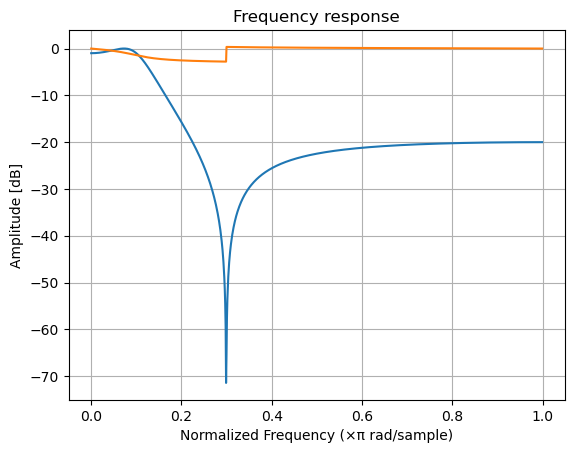

In [5]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
#%matplotlib qt 


coef=np.loadtxt("filtre.csv", delimiter=',')
b=coef[:,0] # Coefficients of the numerator
a=coef[:,1] # Coefficients of the denominator
print(b,a)
# Point fixed values of the coefficients:
Fc=14 
coef = np.round(coef * 2**Fc) / 2**Fc # rounding to 14 bits
b=coef[:,0]
a=coef[:,1]
#b = [0.109375, -0.125, 0.109375]
#a = [-1.625, 0.71875]
print("new",b,a)

# int8_t values of the coefficients:
coef = np.round(coef * 2**Fc) # rounding to 14 bits
b=coef[:,0]
a=coef[:,1]
#b = [7, -8, 7]
#a = [-104, 46]
print("new 1",b,a)
# Plot the frequency response   
w, h = scipy.signal.freqz(b, a, worN=1024)
plt.plot(w/np.pi, 20 * np.log10(abs(h))) # Magnitude in dB
plt.plot(w/np.pi, np.angle(h)) # Phase in radians
plt.title('Frequency response')
plt.xlabel('Normalized Frequency (×π rad/sample)')
plt.ylabel('Amplitude [dB]')
plt.grid()
plt.show()

